### setup


In [13]:
import functools

import matplotlib.pyplot as plt
import numpy as np
import torch
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from torch import nn
from utils import demo_fn
from pathlib import Path

REPO = Path.cwd().parent

ds = LeRobotDataset("dream_robot/pick_place_cube", root=REPO / "data/robosuite/pick_place_cube")

state = np.asarray(ds.hf_dataset["observation.state"], dtype=np.float32)
action = np.asarray(ds.hf_dataset["action"], dtype=np.float32)
print(f"{state.shape=}")
print(f"{action.shape=}")

top = np.zeros((len(ds), 3, 128, 128), dtype=np.uint8)
for i in range(len(ds)):
    top[i] = (np.asarray(ds[i]["observation.images.top"]) * 255).astype(np.uint8)

print(f"{top.shape=}")

episode = np.asarray(ds.hf_dataset["episode_index"])
val_eps = np.random.default_rng(0).permutation(25)[:5]
is_val = np.isin(episode, val_eps)

state.shape=(5288, 8)
action.shape=(5288, 8)
top.shape=(5288, 3, 128, 128)


In [14]:
for n, a in [("constant", action.mean(0)), ("identity", state)]:
    print("-" * 10)
    print(f"{n} :", np.abs(action - a).mean().round(4))
    per_dim = np.abs(action - a).mean(0)
    print(f"{n} per-dim:", per_dim.round(4))
    print(f"{n} arm:", per_dim[:-1].mean().round(4))
    print(f"{n} gripper:", per_dim[-1].round(4))

----------
constant : 0.1571
constant per-dim: [0.1378 0.1674 0.0257 0.1113 0.0495 0.1377 0.1662 0.4614]
constant arm: 0.1137
constant gripper: 0.4614
----------
identity : 0.0719
identity per-dim: [0.0125 0.051  0.0062 0.0336 0.0047 0.0298 0.0154 0.422 ]
identity arm: 0.0219
identity gripper: 0.422


### linear state only


In [15]:
torch.manual_seed(0)
# hold out 5 whole episodes, not 5 random frames -- neighbouring frames at 30 Hz
# are nearly identical, so a frame split leaks the answer into validation

Xtr, Ytr = torch.tensor(state[~is_val]), torch.tensor(action[~is_val])
Xva, Yva = torch.tensor(state[is_val]), torch.tensor(action[is_val])
print("train", len(Xtr), "val", len(Xva))

net = nn.Linear(8, 8)
opt = torch.optim.AdamW(net.parameters(), lr=1e-2)
for step in range(2001):
    i = torch.randint(0, len(Xtr), (256,))
    loss = (net(Xtr[i]) - Ytr[i]).abs().mean()  # L1
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 500 == 0:
        with torch.no_grad():
            val = (net(Xva) - Yva).abs().mean()
        print(f"{step:5d}  train {loss.item():.4f}  val {val.item():.4f}")

with torch.no_grad():
    per_dim = (net(Xva) - Yva).abs().mean(0).numpy()
    print("per-dim val:", per_dim.round(4))
    print(f"linear arm:", per_dim[:-1].mean().round(4))
    print(f"linear gripper:", per_dim[-1].round(4))

train 4218 val 1070
    0  train 1.6270  val 1.5461
  500  train 0.0436  val 0.0406
 1000  train 0.0412  val 0.0368
 1500  train 0.0326  val 0.0350
 2000  train 0.0359  val 0.0337
per-dim val: [0.0097 0.0199 0.0062 0.0187 0.0113 0.0259 0.0118 0.1658]
linear arm: 0.0148
linear gripper: 0.1658


### top camera


picks=array([431, 504, 577, 650])


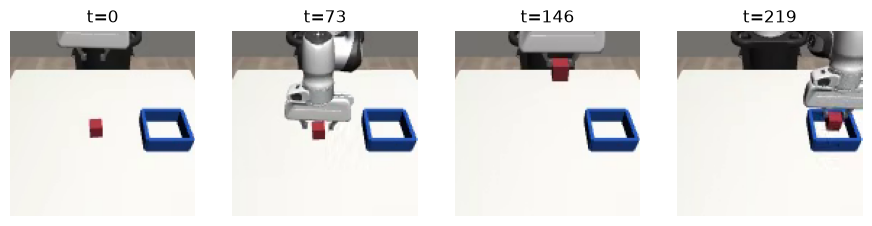

In [16]:
rows = np.flatnonzero(episode == 2)
picks = rows[[0, len(rows) // 3, 2 * len(rows) // 3, -1]]
print(f"{picks=}")
fig, ax = plt.subplots(1, 4, figsize=(11, 3))
for a, r in zip(ax, picks):
    a.imshow(top[r].transpose(1, 2, 0))
    a.axis("off")
    a.set_title(f"t={r - rows[0]}")

### pixels + gap


In [17]:
torch.manual_seed(0)
dev = "cuda"
IMtr = torch.tensor(top[~is_val]).to(dev)
IMva = torch.tensor(top[is_val]).to(dev)
Xtr = torch.tensor(state[~is_val]).to(dev)
Xva = torch.tensor(state[is_val]).to(dev)
Ytr = torch.tensor(action[~is_val]).to(dev)
Yva = torch.tensor(action[is_val]).to(dev)


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # 128 -> 64 -> 32 -> 16, ending with 64 feature maps of 16x16
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 5, 2, 2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.ReLU(),
        )
        self.head = nn.Sequential(nn.Linear(64 + 8, 512), nn.ReLU(), nn.Linear(512, 8))

    def forward(
        self,
        im,  # [B, C, H, W] = [32, 3, 128, 128]
        st,  # [B, 8] = [32, 8]
    ):
        cr = self.conv(im)  # [B, OC, H', W'] = [32, 64, 16, 16]
        f = cr.mean(dim=(2, 3))  # [B, OC] = [32, 64]
        catr = torch.cat([f, st], -1)  # [B, OC + 8] = [32, 72]
        out = self.head(catr)  # [B, 8] = [32, 8]
        return out


net = Net().to(dev)
print("params", sum(p.numel() for p in net.parameters()) / 1e6)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3)

for step in range(3001):
    i = torch.randint(0, len(Xtr), (64,), device=dev)
    loss = (net(IMtr[i].float() / 255, Xtr[i]) - Ytr[i]).abs().mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 500 == 0:
        net.eval()
        with torch.no_grad():
            p = torch.cat(
                [
                    net(IMva[j : j + 256].float() / 255, Xva[j : j + 256])
                    for j in range(0, len(Xva), 256)
                ]
            )
            v = (p - Yva).abs().mean(0)
        net.train()
        print(f"{step:5d} train {loss.item():.4f}  val arm {v[:7].mean():.4f}  grip {v[7]:.4f}")


params 0.210056
    0 train 0.8830  val arm 0.8888  grip 0.3867
  500 train 0.0472  val arm 0.0175  grip 0.1516
 1000 train 0.0269  val arm 0.0170  grip 0.1228
 1500 train 0.0171  val arm 0.0126  grip 0.0696
 2000 train 0.0164  val arm 0.0105  grip 0.0536
 2500 train 0.0102  val arm 0.0095  grip 0.0476
 3000 train 0.0110  val arm 0.0086  grip 0.0349


### pixels + softmax


In [18]:
torch.manual_seed(0)
dev = "cuda"
IMtr = torch.tensor(top[~is_val]).to(dev)
IMva = torch.tensor(top[is_val]).to(dev)
Xtr = torch.tensor(state[~is_val]).to(dev)
Xva = torch.tensor(state[is_val]).to(dev)
Ytr = torch.tensor(action[~is_val]).to(dev)
Yva = torch.tensor(action[is_val]).to(dev)


class SpatialSoftmax(nn.Module):
    def __init__(self, h, w):
        super().__init__()
        # log T, not T, so the parameter is unconstrained and T stays > 0
        self.log_t = nn.Parameter(torch.zeros(()))
        v, u = torch.meshgrid(torch.linspace(-1, 1, h), torch.linspace(-1, 1, w), indexing="ij")
        self.register_buffer("grid_u", u.reshape(-1))  # [H'*W']
        self.register_buffer("grid_v", v.reshape(-1))

    def forward(self, f):  # f: [B, OC, H', W']
        B, OC, H, W = f.shape
        flat = f.reshape(B * OC, H * W) / self.log_t.exp()
        a = torch.softmax(flat, dim=-1)  # [B*OC, H'*W'], sums to 1 per channel
        x = a @ self.grid_u  # [B*OC]  expectation = one matmul
        y = a @ self.grid_v
        return torch.stack([x, y], -1).reshape(B, OC * 2)  # [B, 2*OC]


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # 128 -> 64 -> 32 -> 16, ending with 64 feature maps of 16x16
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 5, 2, 2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, 1, 1),
        )
        self.ss = SpatialSoftmax(16, 16)
        self.head = nn.Sequential(nn.Linear(128 + 8, 512), nn.ReLU(), nn.Linear(512, 8))

    def forward(
        self,
        im,  # [B, C, H, W] = [32, 3, 128, 128]
        st,  # [B, 8] = [32, 8]
    ):
        cr = self.conv(im)  # [B, OC, H', W'] = [32, 64, 16, 16]
        f = self.ss(cr)  # [B, 2*OC] = [32, 128]
        catr = torch.cat([f, st], -1)  # [B, 2*OC + 8] = [32, 136]
        out = self.head(catr)  # [B, 8] = [32, 8]
        return out


net = Net().to(dev)
print("params", sum(p.numel() for p in net.parameters()) / 1e6)
opt = torch.optim.AdamW(net.parameters(), lr=1e-3)

for step in range(3001):
    i = torch.randint(0, len(Xtr), (64,), device=dev)
    loss = (net(IMtr[i].float() / 255, Xtr[i]) - Ytr[i]).abs().mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 500 == 0:
        net.eval()
        with torch.no_grad():
            p = torch.cat(
                [
                    net(IMva[j : j + 256].float() / 255, Xva[j : j + 256])
                    for j in range(0, len(Xva), 256)
                ]
            )
            v = (p - Yva).abs().mean(0)
        net.train()
        print(f"{step:5d} train {loss.item():.4f}  val arm {v[:7].mean():.4f}  grip {v[7]:.4f}")


params 0.242825
    0 train 0.9390  val arm 0.9646  grip 0.3820
  500 train 0.0300  val arm 0.0245  grip 0.0612
 1000 train 0.0219  val arm 0.0171  grip 0.0387
 1500 train 0.0156  val arm 0.0225  grip 0.0337
 2000 train 0.0159  val arm 0.0156  grip 0.0237
 2500 train 0.0171  val arm 0.0146  grip 0.0286
 3000 train 0.0113  val arm 0.0125  grip 0.0216
